# Milestone 3

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

In [13]:
df = pd.read_csv("/content/priceoptima_processed.csv")
df.head()

,Product_ID,City,State,Country,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Ratings,products
0,8691788,Dortmund,Berlin,Germany,Regular,2023-09-18,2023,9,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,5.0,Cycling shorts
1,2174773,Nottingham,England,UK,Premium,2023-12-31,2023,12,08:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,4.0,Lenovo Tab
2,6679610,Geelong,New South Wales,Australia,Regular,2023-04-26,2023,4,04:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,2.0,Sports equipment
3,7232460,Edmonton,Ontario,Canada,Premium,2023-08-05,2023,8,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,4.0,Utility knife
4,4983775,Bristol,England,UK,Premium,2024-10-01,2024,10,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,1.0,Chocolate cookies


In [14]:
df["Date"] = pd.to_datetime(df["Date"])

#**🔹 1️⃣ Demand Behavior Over Time**

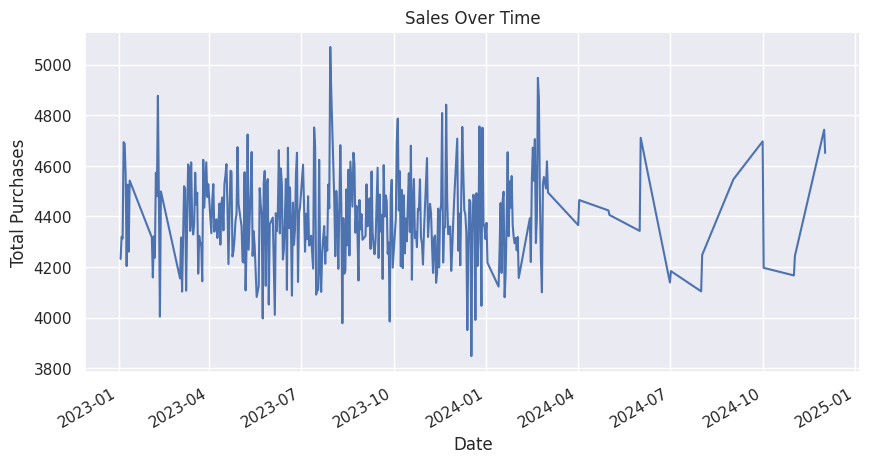

In [15]:
daily_sales = df.groupby("Date")["Total_Purchases"].sum()

plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Purchases")
plt.show()

#**🔹 2️⃣ Price Sensitivity (Amount vs Total_Purchases)**

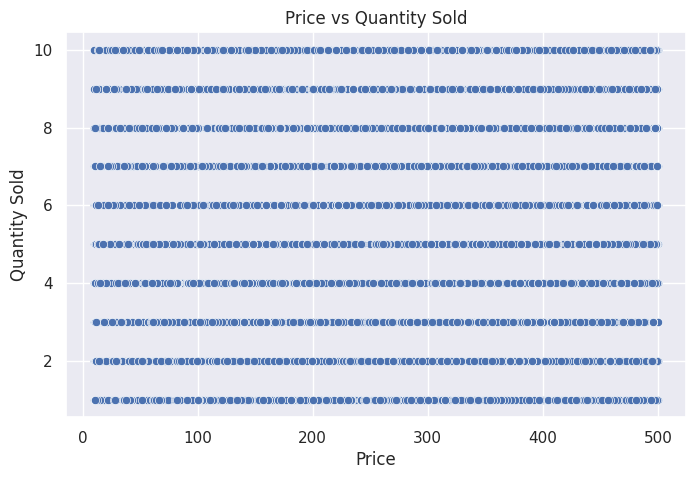

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Amount"], y=df["Total_Purchases"])
plt.title("Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.show()

#**🔹 3️⃣ Revenue Concentration (Total_Amount Analysis)**


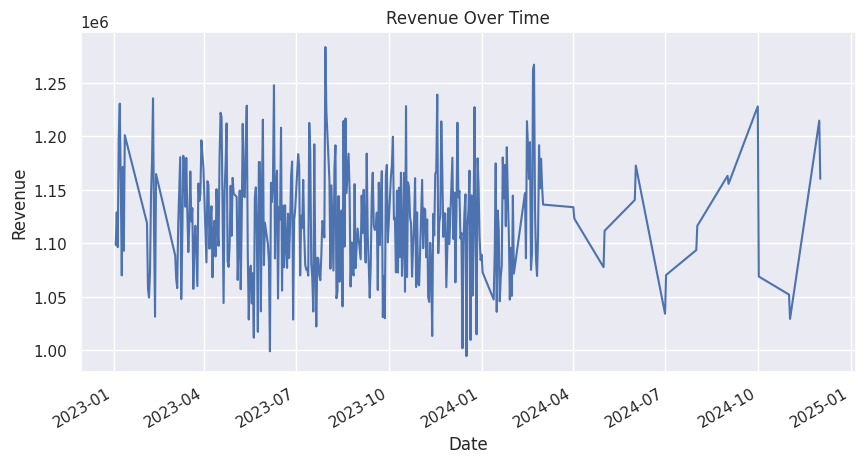

In [17]:
daily_revenue = df.groupby("Date")["Total_Amount"].sum()

plt.figure(figsize=(10,5))
daily_revenue.plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

#**🔹 4️⃣ Product Category Performance**

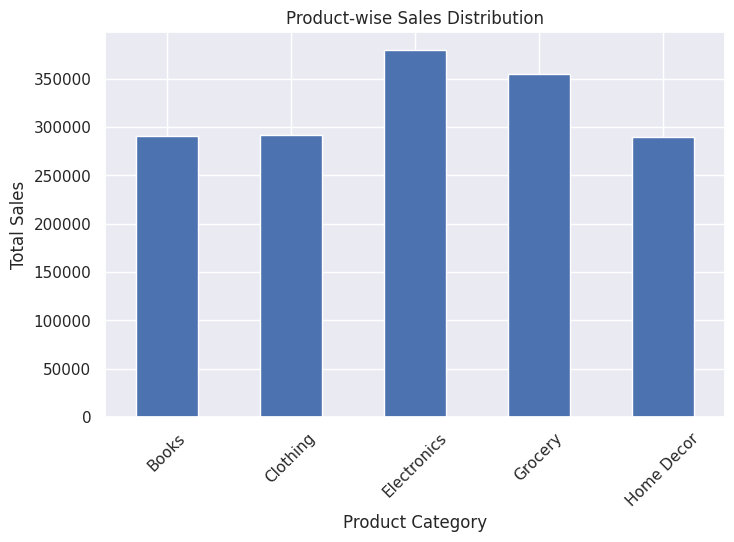

In [18]:
# Group data
product_sales = df.groupby("Product_Category")["Total_Purchases"].sum()
# Plot
plt.figure(figsize=(8,5))
product_sales.plot(kind="bar")
plt.title("Product-wise Sales Distribution")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# **5️⃣ Price Distribution**

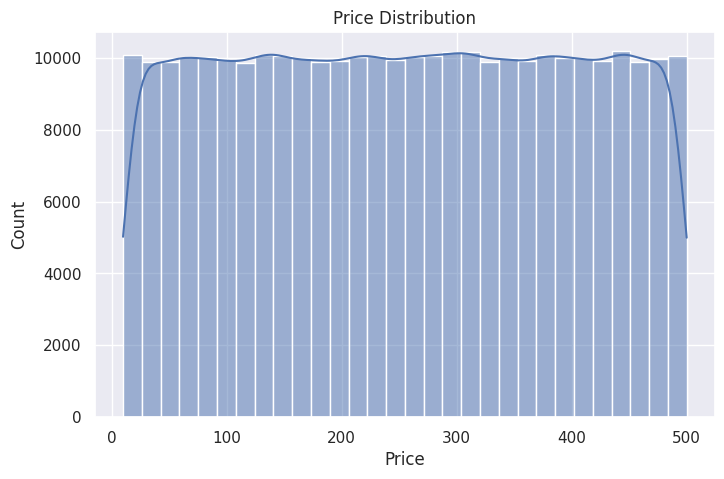

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

#**🔹 6️⃣ Demand Segmentation**

In [23]:
df["Demand_Level"] = pd.qcut(df["Total_Purchases"], q=2, labels=["Low Demand", "High Demand"])
df["Demand_Level"].value_counts()

,count
Demand_Level,
Low Demand,158158
High Demand,141632


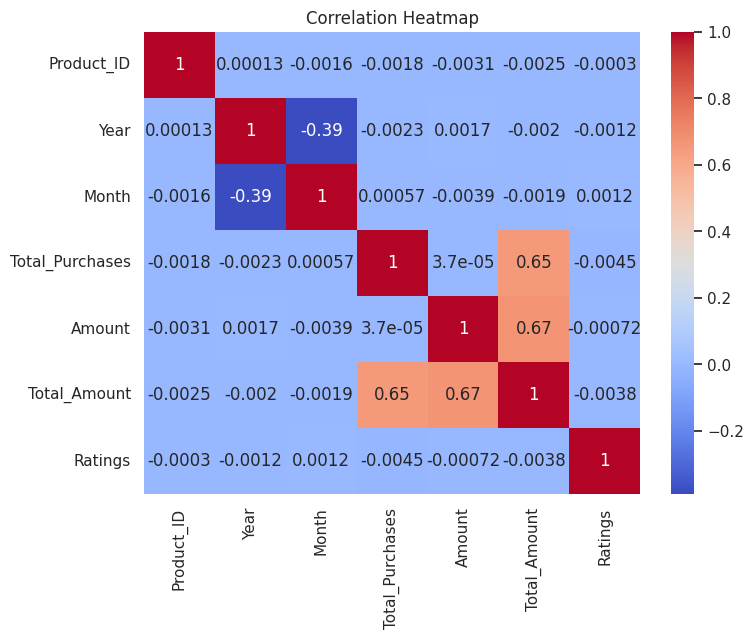

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The strongest visible relationship is between Total_Purchases and Total_Amount (0.65) and between Amount and Total_Amount (0.67). Since these values are close to 1, they show a strong positive correlation.